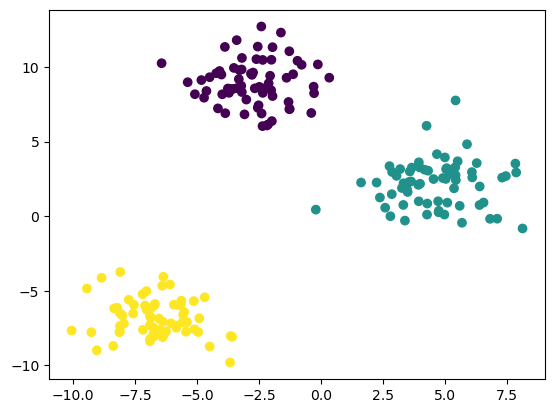

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
# 데이터 생성
X, y = make_blobs(
    n_samples=200, centers=3, cluster_std=1.5, random_state=42
)
# 시각화
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


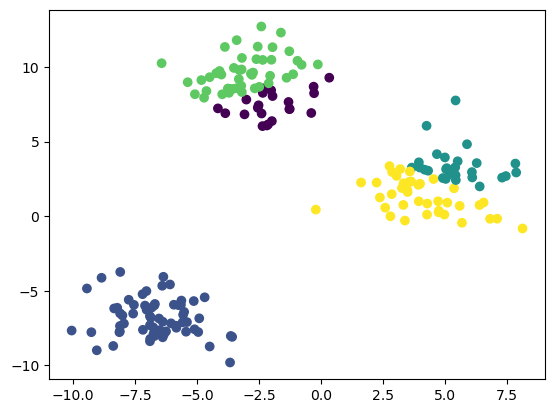

In [15]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=y_pred)
plt.show()

[[-7.95729352 -7.20028032]
 [-8.12311971 -7.72038115]
 [ 2.36082389  1.24681857]]


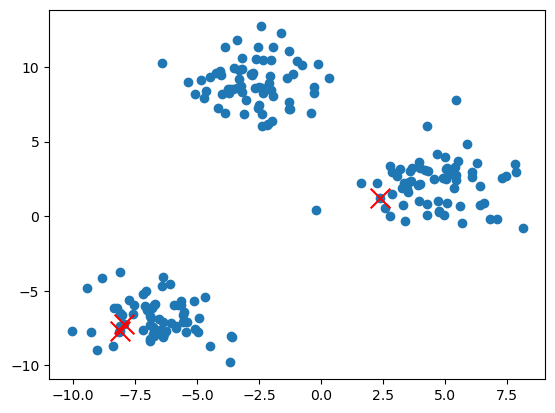

In [46]:
# step 1 - 초기 중심 : 처음 중심을 랜덤으로 선택
import numpy as np
k = 3
np.random.seed(42)
indices = np.random.choice(len(X), k, replace=False)
centroids = X[indices]
print(centroids)
plt.scatter(X[:,0], X[:,1])
plt.scatter(centroids[:,0], centroids[:,1], c='r', marker='x', s=200)

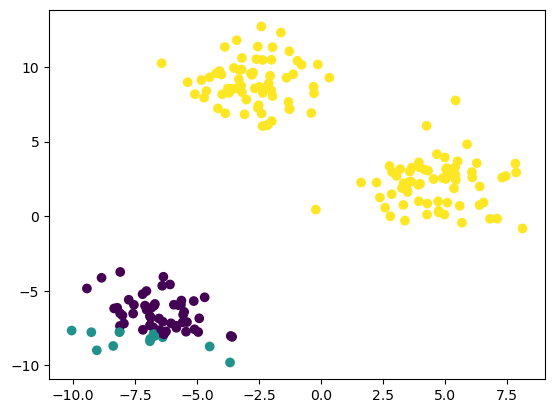

In [ ]:
# step 2 각 점을 가장 가까운 중심에 할당
# 거리계산 => 가장 가까운 중심 선택
def assign_cluster(X, centroids):
    distance = np.linalg.norm(X[:,np.newaxis] - centroids, axis=2)
    return np.argmin(distance, axis=1)

labels = assign_cluster(X,centroids)
# 각 점이 0, 1, 2 중 하나로 배정됨
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

In [ ]:
X[:,np.newaxis].shape, X.shape, centroids.shape
# 점 200개 x centroid 3개 x 좌표 2
# 첫 번째 점 [1,2]
# centroid : [3, 4], [5, 6], [7,8]
# 모든 centroids와의 좌표 계산
# 거리계산 (np.linalg.norm)  (X차이**2 + y차이**2)**(1/2) axis=2 좌표방향

((200, 1, 2), (200, 2), (3, 2))

In [ ]:
X[:,np.newaxis] - centroids

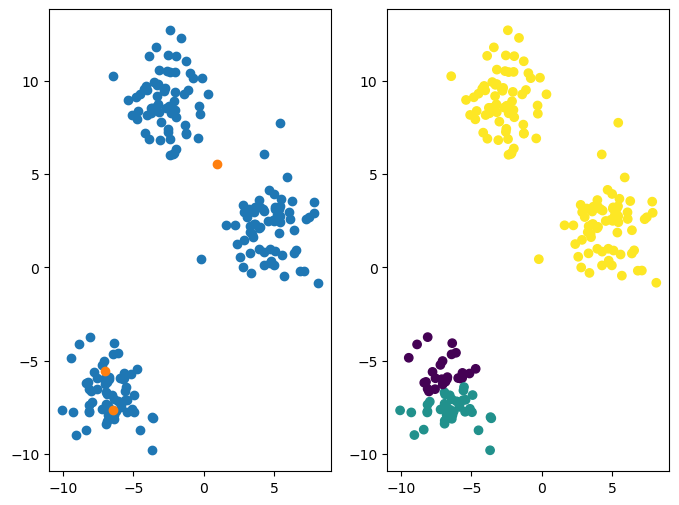

In [ ]:
# step 3 중심 이동
# 각 그룹의 평균을 계산 => 새로운 중심
def update_centroid(X,labels,k):
    return np.array(
        [ X[labels==i].mean(axis=0) for i in range(k) ]
    )

centroids = update_centroid(X,labels,k)   

# 새로운 중심점을 좌표에 업데이트
# 2. 새로운 중심점을 기준으로 label을 분리해서 시각화
fig, ax = plt.subplots(1, 2, figsize=(8,6))
ax[0].scatter(X[:,0], X[:,1])
ax[0].scatter(centroids[:,0], centroids[:,1])

labels = assign_cluster(X,centroids)
ax[1].scatter(X[:,0], X[:,1], c=labels)

In [57]:
# 데이터준비
# 임의의 중심점 생성
# 중심점 주변의 데이터의 라벨을 설정
# 같은 라벨끼리 평균을 구해서 중심점 업데이트
# 새로운중심점으로 라벨을 할당

# update_centroid
# assign_cluster
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
# 데이터 생성
X,y = make_blobs(
    n_samples=200, centers=3, cluster_std=1.5, random_state=42
)

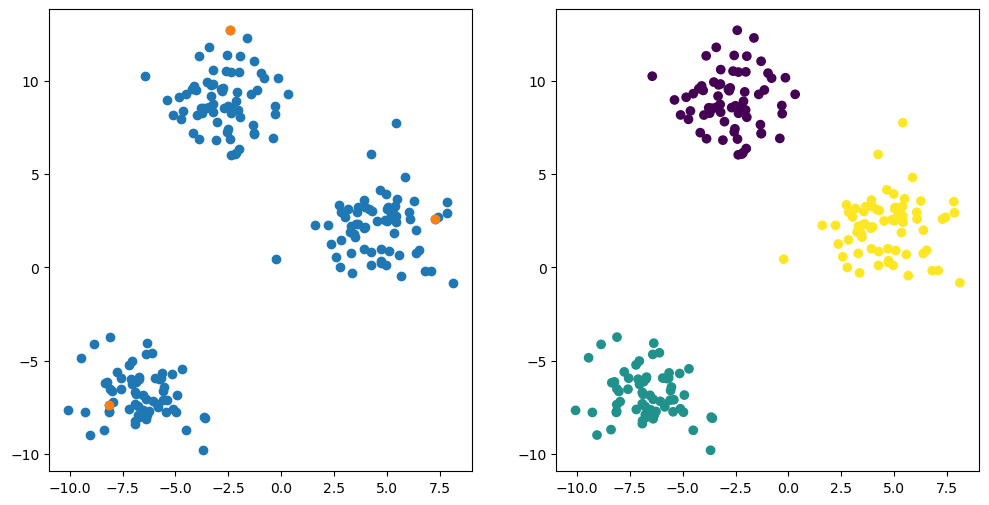

In [58]:
k = 3
indices = np.random.choice(len(X), k, replace=False)
centroids = X[indices]

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(X[:,0], X[:,1])   
ax[0].scatter(centroids[:,0],centroids[:,1]) 

labels = assign_cluster(X,centroids)
ax[1].scatter(X[:,0], X[:,1],c=labels)  

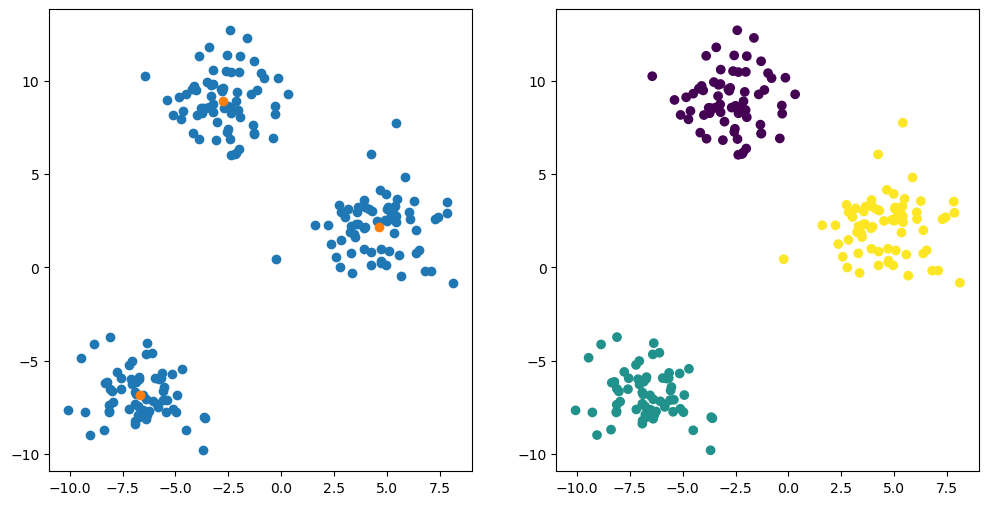

In [78]:
label = assign_cluster(X,centroids)
new_centroid = update_centroid(X,label,k)

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(X[:,0], X[:,1])   
ax[0].scatter(centroids[:,0],centroids[:,1]) 

labels = assign_cluster(X,centroids)
ax[1].scatter(X[:,0], X[:,1],c=labels)  
plt.show() 

centroids = new_centroid

c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

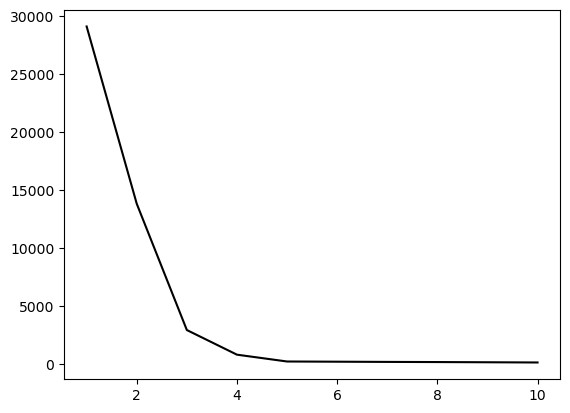

In [50]:
# 최적의 k개수 찾기 - Elbow Method (기본)
# k가 증가할수록 오차는 감소
# 어느순간 감소 폭이 급격히 줄어드는 지점
X, y = make_blobs(
    n_samples=500, centers=5, cluster_std=0.5, random_state=42
)

k_range = range(1,11)
wcss = []
for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(k_range,wcss,'-0')
plt.show()


In [52]:
# 실루엣 score
# 같은 클러스터 끼리는 가깝고 다른 클러스터와는 멀어야 좋다 -1~1
from sklearn.metrics import silhouette_score
scores = []
k_range = range(2,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
scores
np.argmax(scores) + 2

c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

np.int64(5)

In [ ]:
# elbow로 확인
# silhouette 확인
# 데이터 시각화

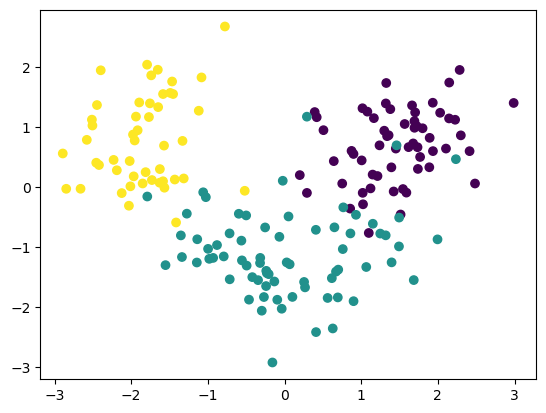

c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

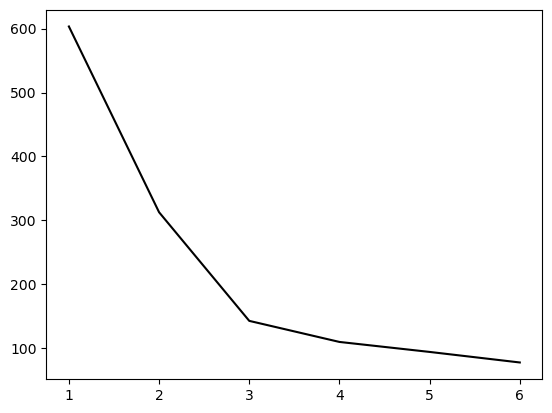

In [91]:
# 와인 데이터 정답(품질)을 제거한 후 k_means로 크러스터를 분리... 최적의 k를 찾기
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

data = load_wine()
X = data.data
y = data.target

pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('pca', PCA(n_components=2))
])
X_preprocess = pipe.fit_transform(X)
plt.scatter(X_preprocess[:,0], X_preprocess[:,1],c=y)
plt.show()

k_range = range(1,7)
wcss = []
for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_preprocess)
    wcss.append(kmeans.inertia_)
plt.plot(k_range,wcss,'-0')
plt.show()


c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

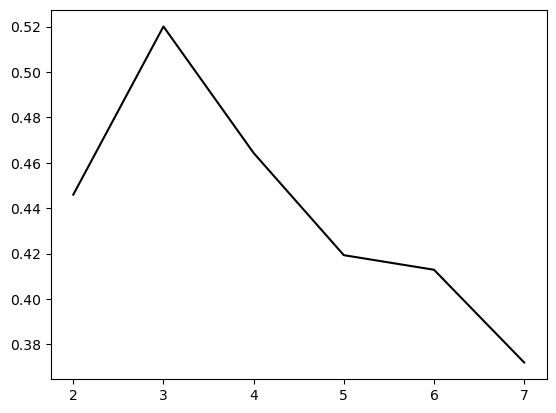

In [93]:
from sklearn.metrics import silhouette_score
scores = []
k_range = range(2,8)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_preprocess)
    score = silhouette_score(X_preprocess, labels)
    scores.append(score)
scores
np.argmax(scores) + 2
plt.plot(k_range,scores,'-0')

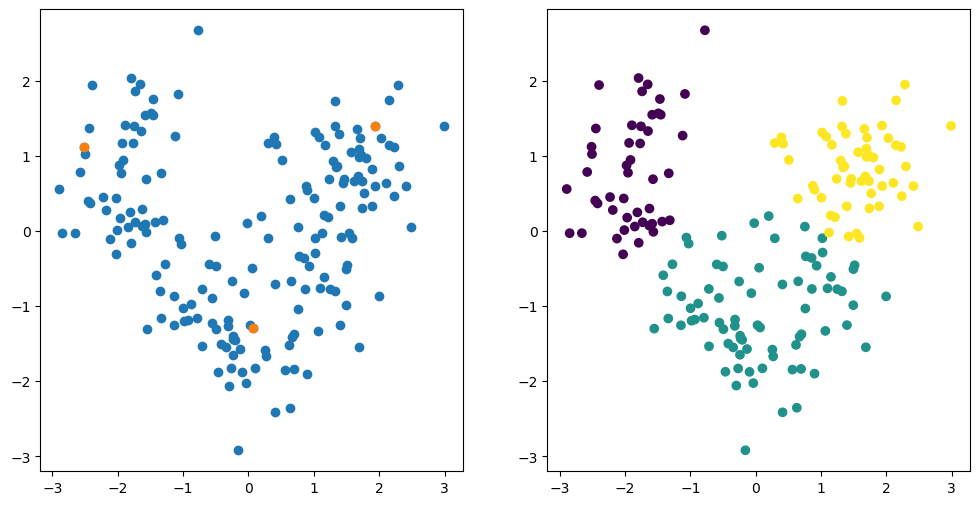

In [95]:
k = 3
indices = np.random.choice(len(X), k, replace=False)
centroids = X_preprocess[indices]

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(X_preprocess[:,0], X_preprocess[:,1])   
ax[0].scatter(centroids[:,0],centroids[:,1]) 

labels = assign_cluster(X_preprocess,centroids)
ax[1].scatter(X_preprocess[:,0], X_preprocess[:,1],c=labels)  

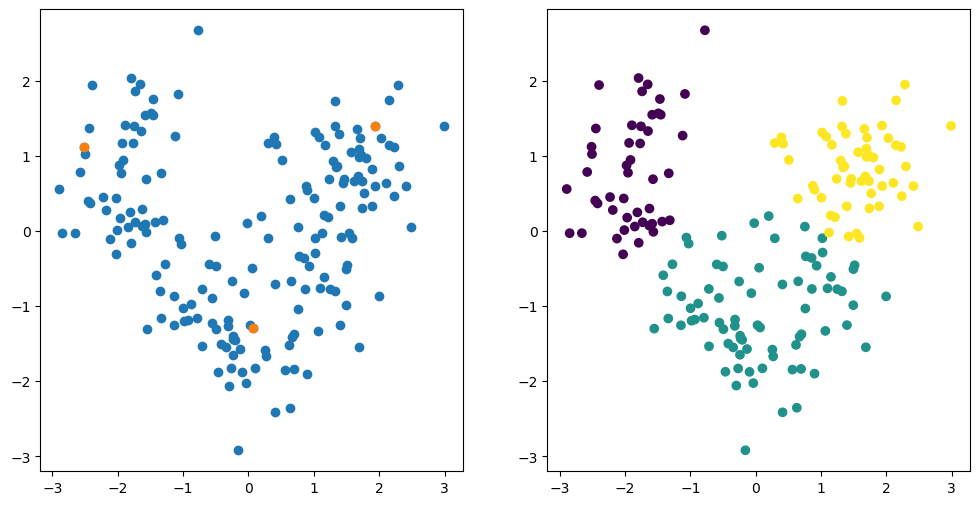

In [120]:
label = assign_cluster(X_preprocess,centroids)
new_centroid = update_centroid(X_preprocess,label,k)

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(X_preprocess[:,0], X_preprocess[:,1])   
ax[0].scatter(centroids[:,0],centroids[:,1]) 

labels = assign_cluster(X_preprocess,centroids)
ax[1].scatter(X_preprocess[:,0], X_preprocess[:,1],c=labels)  
plt.show() 

In [85]:
X[0]

array([1.423e+01, 1.710e+00, 2.430e+00, 1.560e+01, 1.270e+02, 2.800e+00,
       3.060e+00, 2.800e-01, 2.290e+00, 5.640e+00, 1.040e+00, 3.920e+00,
       1.065e+03])